In [7]:
import time
import numpy as np
from examples.seismic import SeismicModel, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver
from examples.seismic.datasets import SeismogramDataset, VelocityModel
from devito import info, TimeFunction, Function, Eq, Operator, norm, inner
from examples.seismic.utils import taper_wavelet, estimate_centroid_frequency_gather
from devito import configuration
from matplotlib import pyplot as plt
from config import setup_model_and_geometry
from config import PATH_DATA_DPLUS, TMAX, SO
configuration["platform"] = "nvidiaX"
configuration["language"] = "openacc"
configuration["compiler"] = "nvc"
configuration["log-level"] = "ERROR"

In [8]:
from matplotlib import rc
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import ListedColormap
rc("font", family="serif")
rc("pgf", texsystem="pdflatex")
rc("text", usetex=True)
# rc('text.latex', unicode=True)
rc("text.latex", preamble=r"\usepackage{amssymb}")
rc("text.latex", preamble=r"\usepackage[T1,T2A]{fontenc}")
rc("text.latex", preamble=r"\usepackage[utf8]{inputenc}")
rc("text.latex", preamble=r"\usepackage[english,russian]{babel}")

In [9]:
model, dataset, velmodel = setup_model_and_geometry(path_data=PATH_DATA_DPLUS)
dataset._dt_r = model.critical_dt
dataset._t_max_r = TMAX
dataset.resample_on()

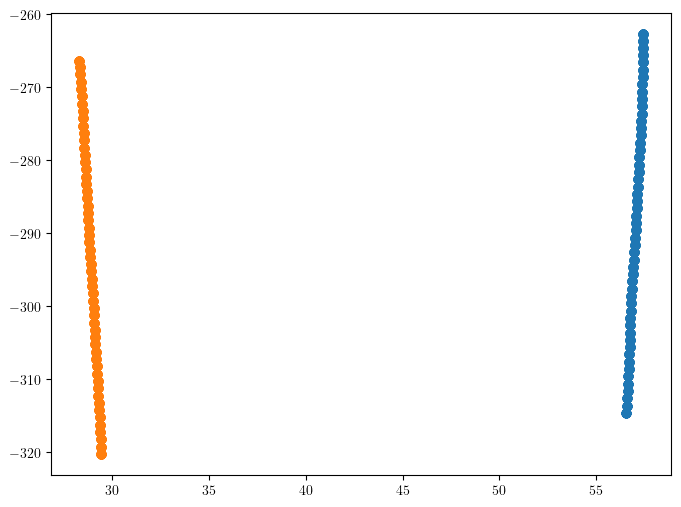

In [10]:
plt.scatter(dataset.x_coords, dataset.elevations)
plt.scatter(dataset.opposite_x, dataset.opposite_elev)
plt.show()

In [11]:
len(dataset)

53

In [12]:
def calculate_step_size(misfit, h):
    # Compute numerator and denominator for step size
    numerator = np.dot(misfit.reshape(-1), h.reshape(-1))
    denominator = np.dot(h.reshape(-1), h.reshape(-1))
    return numerator / denominator

from scipy.signal.windows import tukey

def left_taper_tukey(signal, alpha=0.5):
    """
    Taper the left side of a signal using a Tukey window.
    
    Args:
        signal (np.ndarray): Input signal (gradient).
        alpha (float): Shape parameter of the Tukey window (0=rectangular, 1=Hann).
    
    Returns:
        np.ndarray: Tapered signal.
    """
    n = len(signal)
    signal[0] = 0.
    window = tukey(n * 2, alpha=alpha)[:n]  # Take left half of symmetric window
    return signal * window, window

In [13]:
def set_wavelet_in_geometry(geometry, wavelet_1d):
    """
    geometry.src.data expects (nt, nsrc). We pass the same time series for each source (nsrc==1 here).
    wavelet_1d: shape (nt,)
    """
    w = np.asarray(wavelet_1d).reshape(-1, 1)
    geometry._src_type = None          # let us override with raw samples
    geometry.wav_data = w.reshape(-1)  # keep for our own bookkeeping
    geometry.src.data[:] = w

def forward_data(model, geometry, solver):
    """
    Return synthetic receiver data y = G f for the current geometry.src.data.
    """
    d_syn = Receiver(name='d_syn',
                     grid=model.grid,
                     time_range=geometry.time_axis,
                     coordinates=geometry.rec_positions)
    solver.forward(vp=model.vp, src=geometry.src, rec=d_syn, save=False)
    return np.array(d_syn.data)

def adjoint_to_source(model, geometry, solver, rec_traces):
    """
    Apply G^T to 'rec_traces' (shape (nt, nrec)), i.e. inject at receivers, backprop, sample at source.
    Returns a 1D array of length nt (B^T L^{-T} S^T rec_traces).
    """
    d = Receiver(name='d', grid=model.grid, time_range=geometry.time_axis,
                 coordinates=geometry.rec_positions)
    d.data[:] = rec_traces
    srca, _, _ = solver.adjoint(vp=model.vp, rec=d)  # srca shape: (nt, nsrc) -> we use a single source
    return np.array(srca.data).reshape(-1)

# --- Right-hand side b = G^T W^T W d
def precompute_b(model, geometry, solver, d_obs):
    """
    d_obs: observed data shaped (nrec, nt) or (nt, nrec). We'll accept your dataset shape.
    """
    # Devito expects (nt, nrec)
    if d_obs.shape[0] != geometry.time_axis.num:
        d_obs_tn = d_obs.T
    else:
        d_obs_tn = d_obs
    b = adjoint_to_source(model, geometry, solver, d_obs_tn)     # G^T W d  (W is self-adjoint)
    return b

# --- Linear operator apply: A v = G^T W G v + lam * v
def apply_A(model, geometry, solver, v, lam=0.0):
    set_wavelet_in_geometry(geometry, v)
    y = forward_data(model, geometry, solver)                 # y = G v  (nt, nrec)
    srca = adjoint_to_source(model, geometry, solver, y)    # G^T W y
    srca, window = left_taper_tukey(srca.reshape(-1), alpha=0.05)
    return srca.reshape(-1) + lam * v

In [14]:
# --- Main loop using exact SD step first, then BB
max_iter = 2
lam = 1e-7
t0 = 0
tn = TMAX

[shot 0] Estimated gather centroid frequency: 261.93 Hz, Wavelet length: 3.82 ms
    iter 01: alpha=3.698e+05, rel||g||=9.278e-01, approx J=-1.970e-04
    iter 02: alpha=7.552e+06, rel||g||=1.666e-01, approx J=-1.425e-03


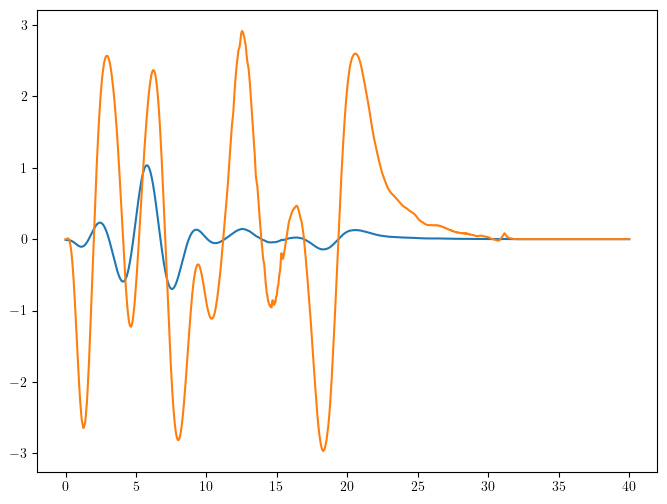

[shot 1] Estimated gather centroid frequency: 301.97 Hz, Wavelet length: 3.31 ms
    iter 01: alpha=3.070e+05, rel||g||=9.481e-01, approx J=-3.343e-04
    iter 02: alpha=6.173e+06, rel||g||=2.070e-01, approx J=-3.490e-03


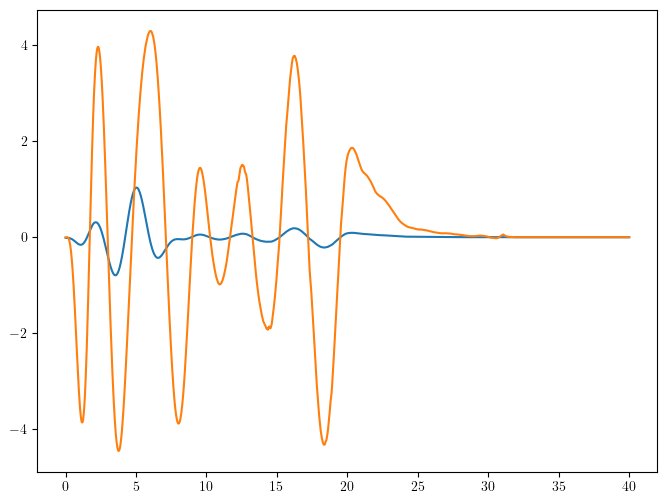

[shot 2] Estimated gather centroid frequency: 291.23 Hz, Wavelet length: 3.43 ms
    iter 01: alpha=2.570e+05, rel||g||=9.237e-01, approx J=-5.801e-04
    iter 02: alpha=5.158e+06, rel||g||=1.458e-01, approx J=-3.885e-03


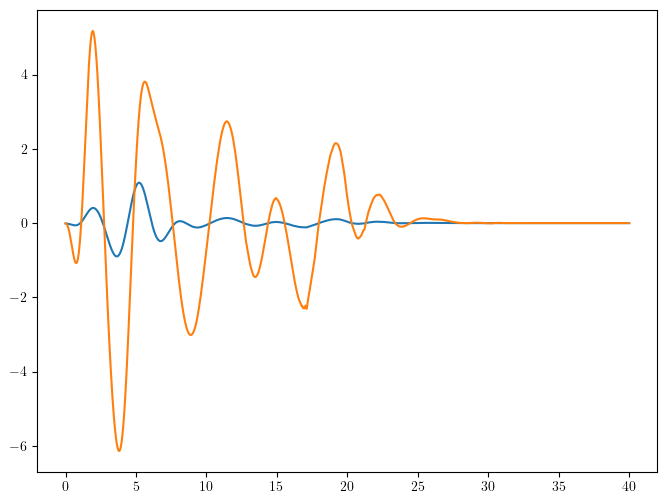

[shot 3] Estimated gather centroid frequency: 291.07 Hz, Wavelet length: 3.44 ms
    iter 01: alpha=2.276e+05, rel||g||=9.265e-01, approx J=-5.392e-04
    iter 02: alpha=4.567e+06, rel||g||=2.700e-01, approx J=-3.406e-03


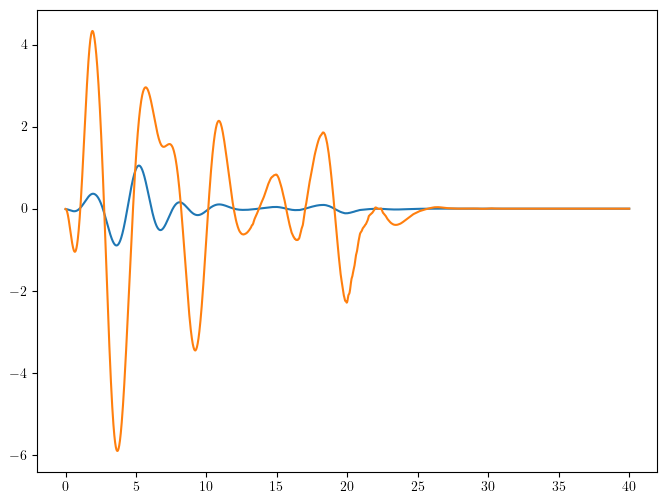

[shot 4] Estimated gather centroid frequency: 280.52 Hz, Wavelet length: 3.56 ms
    iter 01: alpha=2.283e+05, rel||g||=9.616e-01, approx J=-5.880e-04
    iter 02: alpha=4.571e+06, rel||g||=2.436e-01, approx J=-8.408e-03


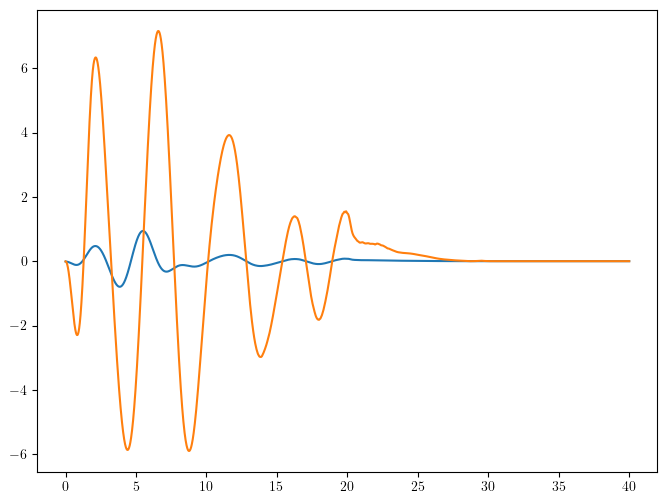

[shot 5] Estimated gather centroid frequency: 321.15 Hz, Wavelet length: 3.11 ms
    iter 01: alpha=2.616e+05, rel||g||=9.521e-01, approx J=-5.502e-04
    iter 02: alpha=5.243e+06, rel||g||=1.737e-01, approx J=-6.347e-03


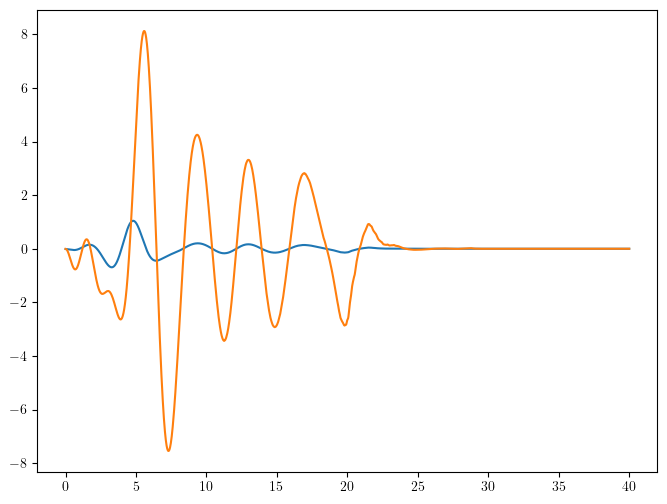

[shot 6] Estimated gather centroid frequency: 351.04 Hz, Wavelet length: 2.85 ms
    iter 01: alpha=2.104e+05, rel||g||=9.834e-01, approx J=-7.683e-05
    iter 02: alpha=4.217e+06, rel||g||=5.203e-01, approx J=-4.600e-03


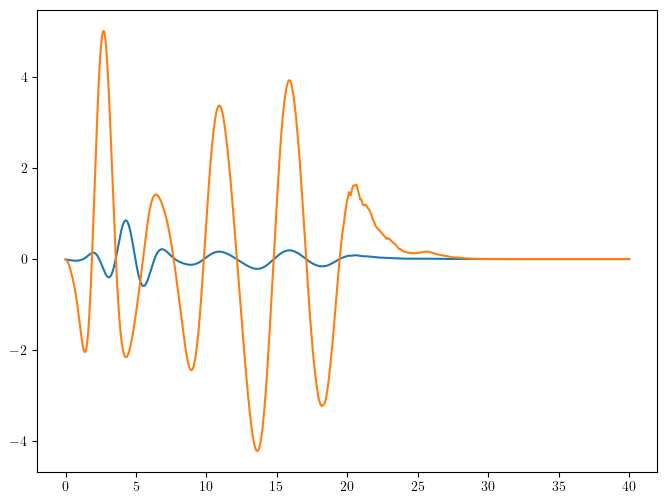

[shot 7] Estimated gather centroid frequency: 343.83 Hz, Wavelet length: 2.91 ms
    iter 01: alpha=2.545e+05, rel||g||=9.338e-01, approx J=-5.738e-04
    iter 02: alpha=5.105e+06, rel||g||=1.537e-01, approx J=-4.605e-03


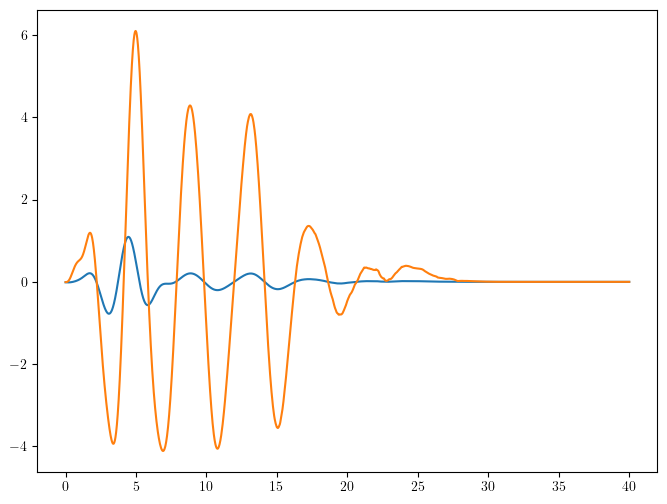

[shot 8] Estimated gather centroid frequency: 356.62 Hz, Wavelet length: 2.80 ms
    iter 01: alpha=2.038e+05, rel||g||=8.906e-01, approx J=-4.398e-04
    iter 02: alpha=4.097e+06, rel||g||=5.851e-01, approx J=-2.012e-03


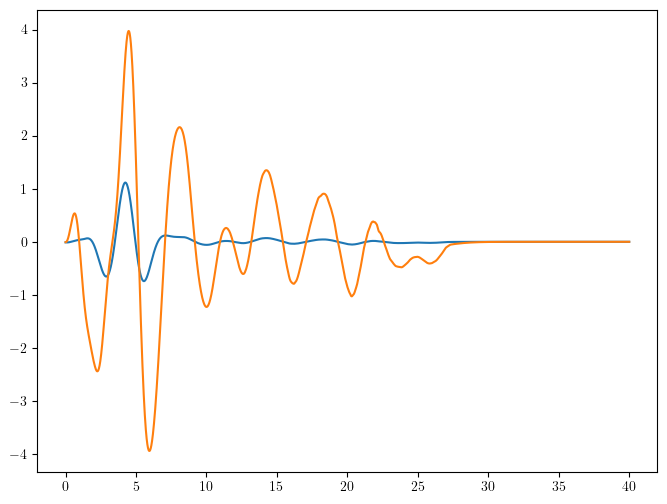

[shot 9] Estimated gather centroid frequency: 330.59 Hz, Wavelet length: 3.02 ms
    iter 01: alpha=2.168e+05, rel||g||=1.010e+00, approx J=6.537e-05
    iter 02: alpha=4.348e+06, rel||g||=2.062e-01, approx J=-2.792e-03


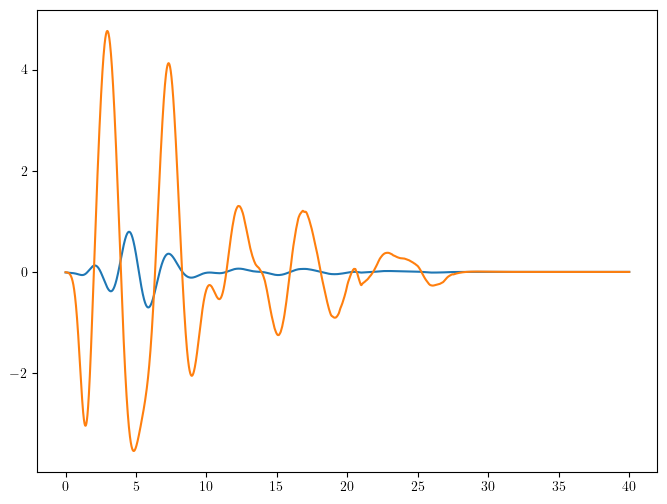

[shot 10] Estimated gather centroid frequency: 353.43 Hz, Wavelet length: 2.83 ms
    iter 01: alpha=2.093e+05, rel||g||=9.811e-01, approx J=-2.963e-05
    iter 02: alpha=4.229e+06, rel||g||=4.714e-01, approx J=-8.523e-04


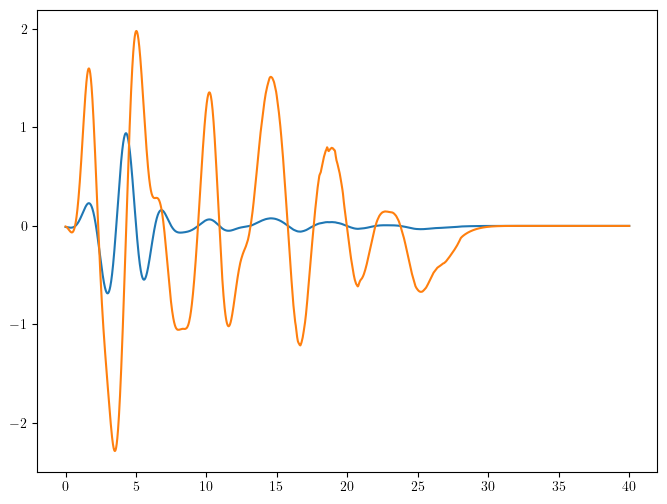

[shot 11] Estimated gather centroid frequency: 397.32 Hz, Wavelet length: 2.52 ms
    iter 01: alpha=2.900e+05, rel||g||=9.128e-01, approx J=-5.533e-04
    iter 02: alpha=5.836e+06, rel||g||=5.393e-01, approx J=-3.178e-03


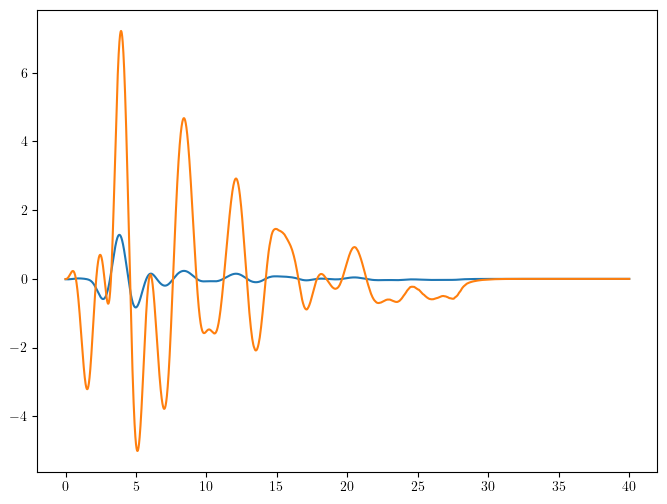

[shot 12] Estimated gather centroid frequency: 409.30 Hz, Wavelet length: 2.44 ms
    iter 01: alpha=2.826e+05, rel||g||=9.466e-01, approx J=-4.486e-04
    iter 02: alpha=5.674e+06, rel||g||=4.790e-01, approx J=-4.274e-03


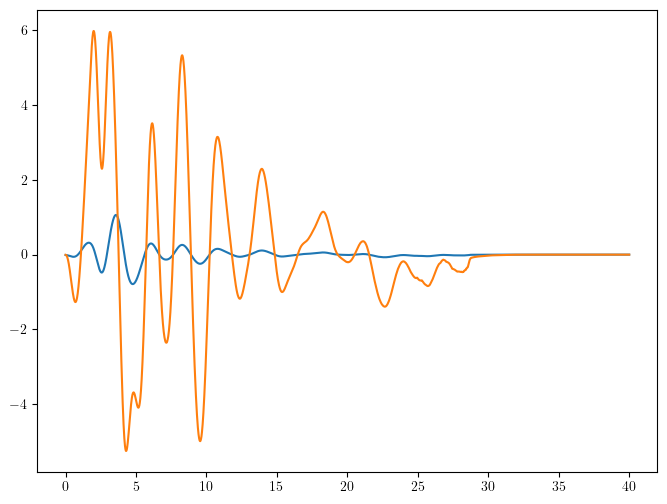

[shot 13] Estimated gather centroid frequency: 427.03 Hz, Wavelet length: 2.34 ms
    iter 01: alpha=3.815e+05, rel||g||=9.485e-01, approx J=-2.284e-03
    iter 02: alpha=7.639e+06, rel||g||=1.750e-01, approx J=-2.267e-02


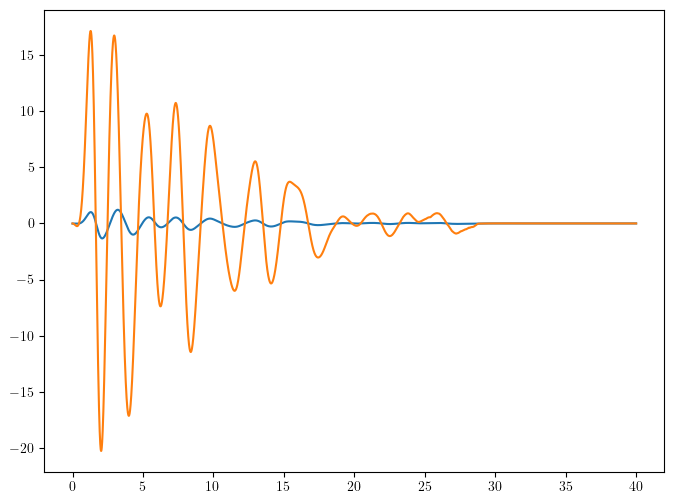

[shot 14] Estimated gather centroid frequency: 368.10 Hz, Wavelet length: 2.72 ms
    iter 01: alpha=2.790e+05, rel||g||=9.621e-01, approx J=-3.861e-03
    iter 02: alpha=5.583e+06, rel||g||=2.341e-01, approx J=-5.270e-02


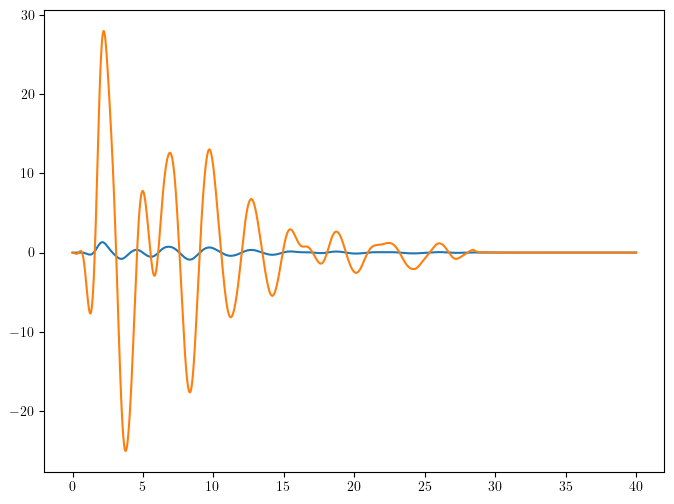

[shot 15] Estimated gather centroid frequency: 371.45 Hz, Wavelet length: 2.69 ms
    iter 01: alpha=2.229e+05, rel||g||=9.476e-01, approx J=-7.126e-03
    iter 02: alpha=4.458e+06, rel||g||=2.065e-01, approx J=-6.822e-02


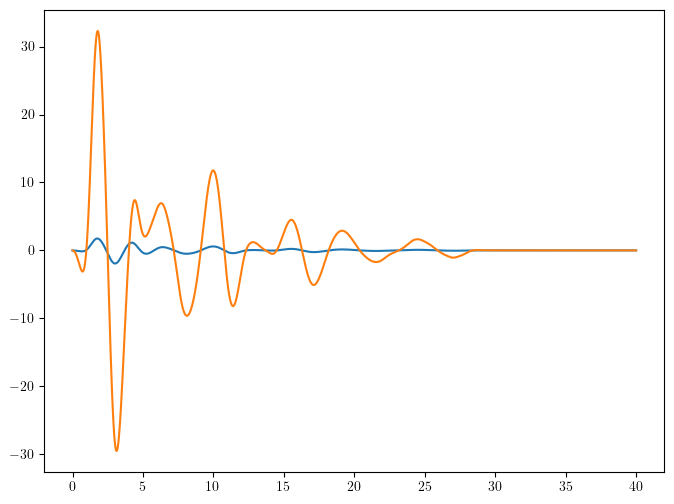

[shot 16] Estimated gather centroid frequency: 335.66 Hz, Wavelet length: 2.98 ms
    iter 01: alpha=1.858e+05, rel||g||=9.501e-01, approx J=-6.474e-03
    iter 02: alpha=3.717e+06, rel||g||=2.977e-01, approx J=-6.401e-02


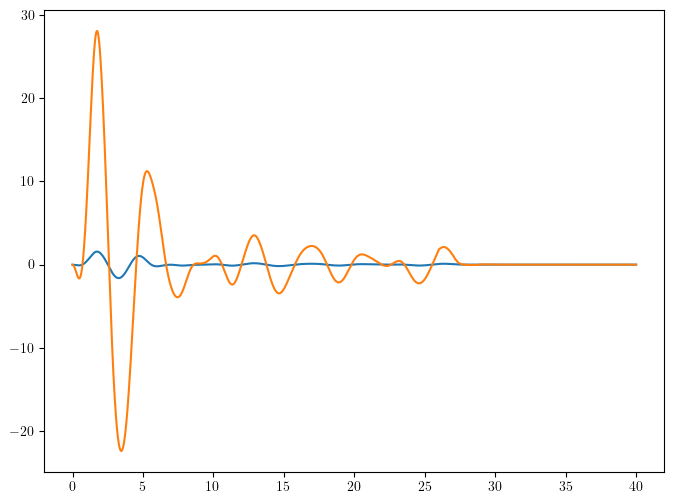

[shot 17] Estimated gather centroid frequency: 365.62 Hz, Wavelet length: 2.74 ms
    iter 01: alpha=2.034e+05, rel||g||=9.554e-01, approx J=-5.278e-03
    iter 02: alpha=4.068e+06, rel||g||=2.457e-01, approx J=-5.967e-02


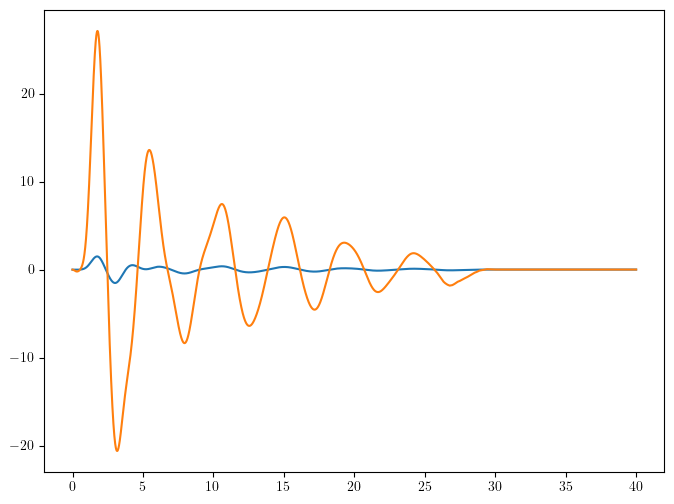

[shot 18] Estimated gather centroid frequency: 354.39 Hz, Wavelet length: 2.82 ms
    iter 01: alpha=2.162e+05, rel||g||=9.596e-01, approx J=-2.547e-03
    iter 02: alpha=4.325e+06, rel||g||=3.568e-01, approx J=-3.244e-02


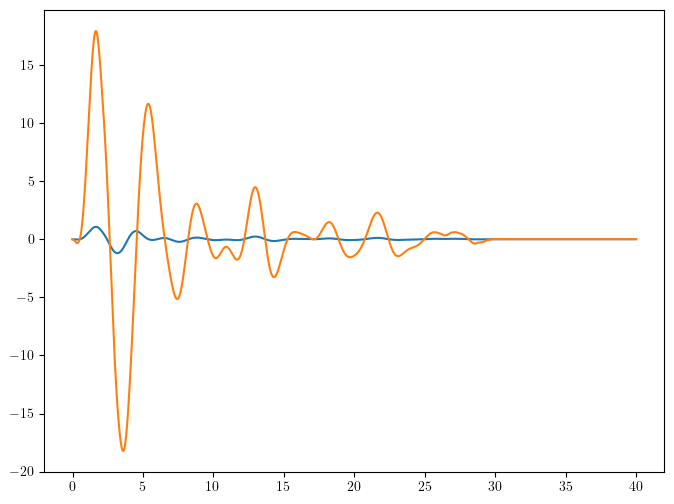

[shot 19] Estimated gather centroid frequency: 334.50 Hz, Wavelet length: 2.99 ms
    iter 01: alpha=2.224e+05, rel||g||=9.570e-01, approx J=-4.612e-03
    iter 02: alpha=4.449e+06, rel||g||=3.239e-01, approx J=-5.564e-02


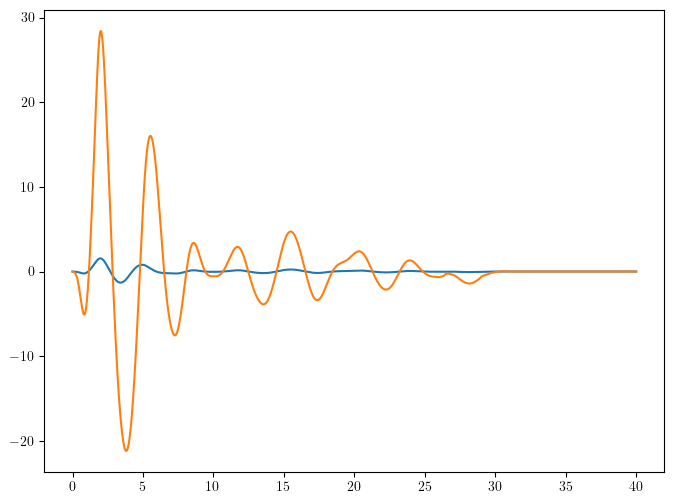

[shot 20] Estimated gather centroid frequency: 339.05 Hz, Wavelet length: 2.95 ms
    iter 01: alpha=2.228e+05, rel||g||=9.516e-01, approx J=-5.965e-03
    iter 02: alpha=4.457e+06, rel||g||=3.372e-01, approx J=-6.306e-02


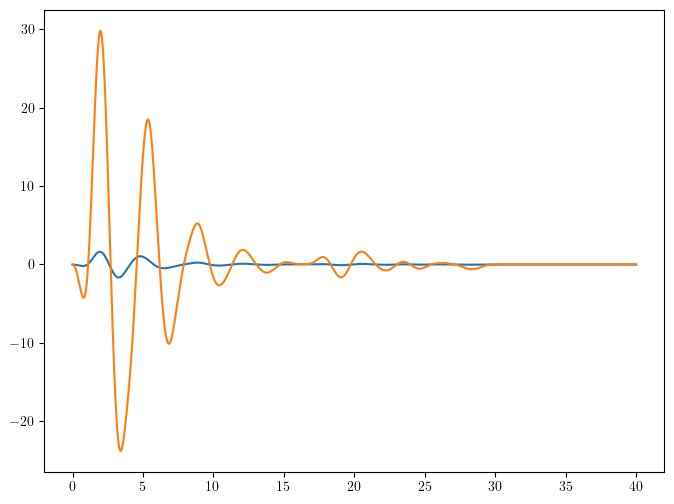

[shot 21] Estimated gather centroid frequency: 314.11 Hz, Wavelet length: 3.18 ms
    iter 01: alpha=1.966e+05, rel||g||=9.437e-01, approx J=-6.167e-03
    iter 02: alpha=3.933e+06, rel||g||=4.368e-01, approx J=-5.498e-02


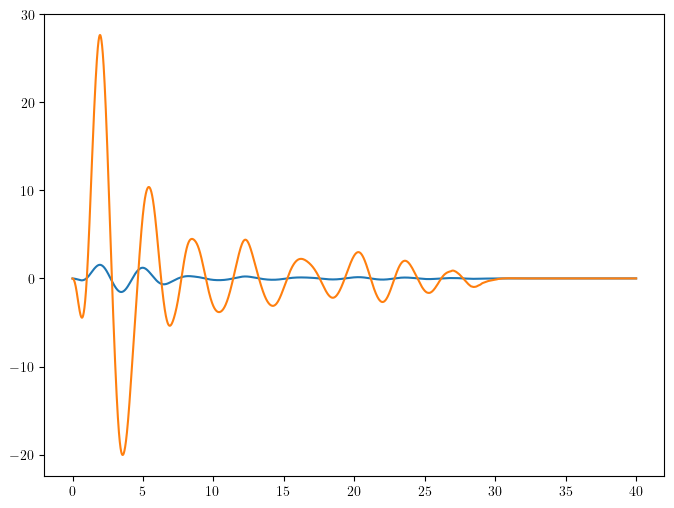

[shot 22] Estimated gather centroid frequency: 355.73 Hz, Wavelet length: 2.81 ms
    iter 01: alpha=2.062e+05, rel||g||=9.516e-01, approx J=-3.981e-03
    iter 02: alpha=4.125e+06, rel||g||=3.482e-01, approx J=-4.166e-02


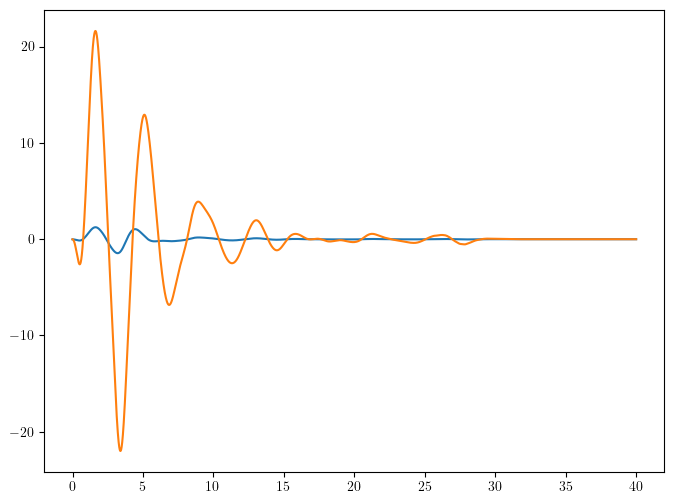

[shot 23] Estimated gather centroid frequency: 351.48 Hz, Wavelet length: 2.85 ms
    iter 01: alpha=1.860e+05, rel||g||=9.534e-01, approx J=-2.825e-03
    iter 02: alpha=3.721e+06, rel||g||=4.597e-01, approx J=-3.033e-02


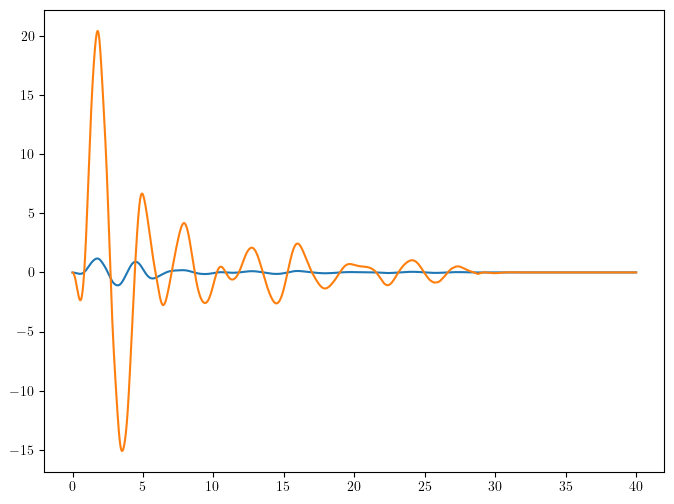

[shot 24] Estimated gather centroid frequency: 404.68 Hz, Wavelet length: 2.47 ms
    iter 01: alpha=2.150e+05, rel||g||=9.648e-01, approx J=-2.111e-03
    iter 02: alpha=4.302e+06, rel||g||=2.397e-01, approx J=-3.124e-02


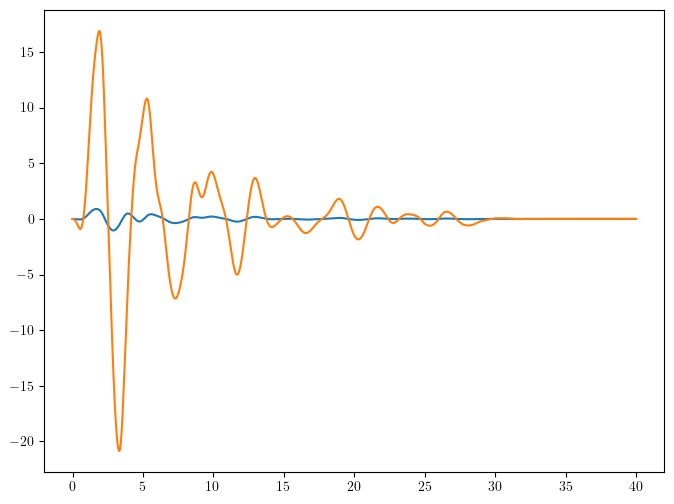

[shot 25] Estimated gather centroid frequency: 366.12 Hz, Wavelet length: 2.73 ms
    iter 01: alpha=1.841e+05, rel||g||=9.654e-01, approx J=-1.259e-03
    iter 02: alpha=3.684e+06, rel||g||=4.008e-01, approx J=-1.877e-02


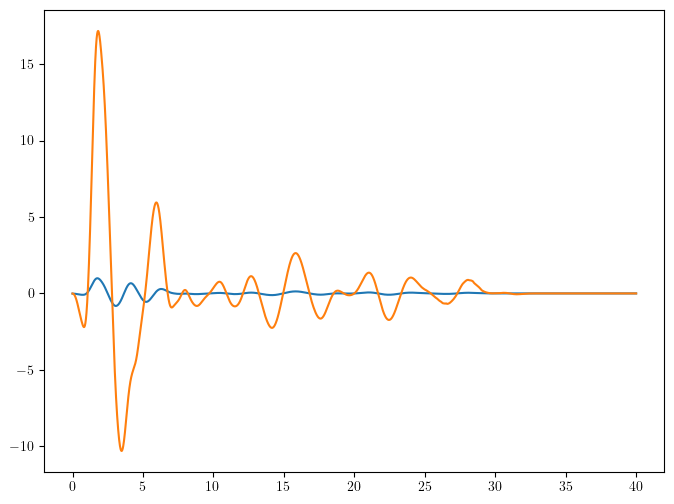

[shot 26] Estimated gather centroid frequency: 455.04 Hz, Wavelet length: 2.20 ms
    iter 01: alpha=2.302e+05, rel||g||=9.904e-01, approx J=-6.946e-05
    iter 02: alpha=4.610e+06, rel||g||=2.550e-01, approx J=-6.315e-03


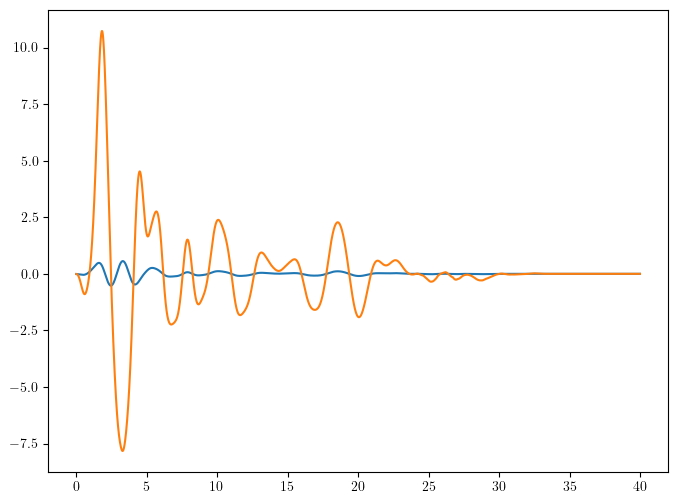

[shot 27] Estimated gather centroid frequency: 462.35 Hz, Wavelet length: 2.16 ms
    iter 01: alpha=2.129e+05, rel||g||=9.656e-01, approx J=-2.793e-04
    iter 02: alpha=4.264e+06, rel||g||=4.129e-01, approx J=-5.369e-03


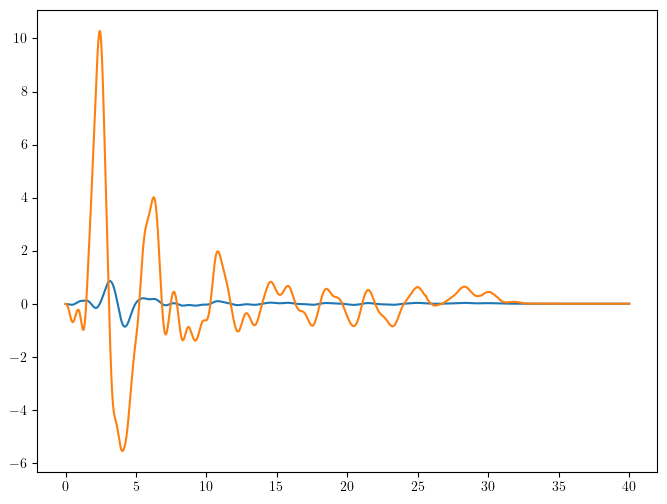

[shot 28] Estimated gather centroid frequency: 466.33 Hz, Wavelet length: 2.14 ms
    iter 01: alpha=2.581e+05, rel||g||=9.898e-01, approx J=-5.508e-05
    iter 02: alpha=5.178e+06, rel||g||=2.179e-01, approx J=-3.853e-03


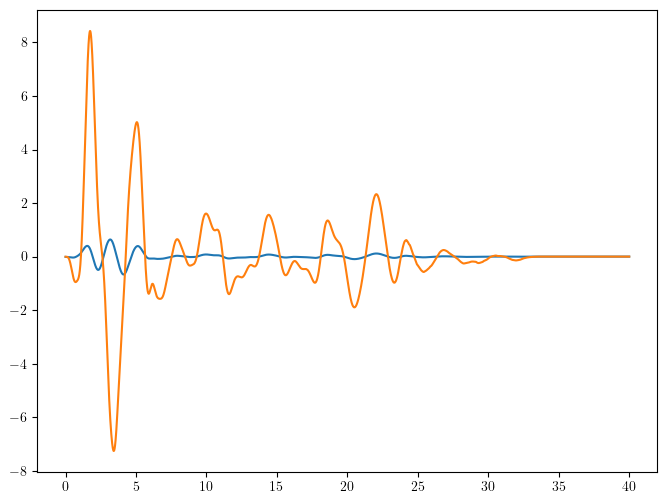

[shot 29] Estimated gather centroid frequency: 535.21 Hz, Wavelet length: 1.87 ms
    iter 01: alpha=2.495e+05, rel||g||=9.812e-01, approx J=-4.408e-05
    iter 02: alpha=5.026e+06, rel||g||=4.950e-01, approx J=-1.666e-03


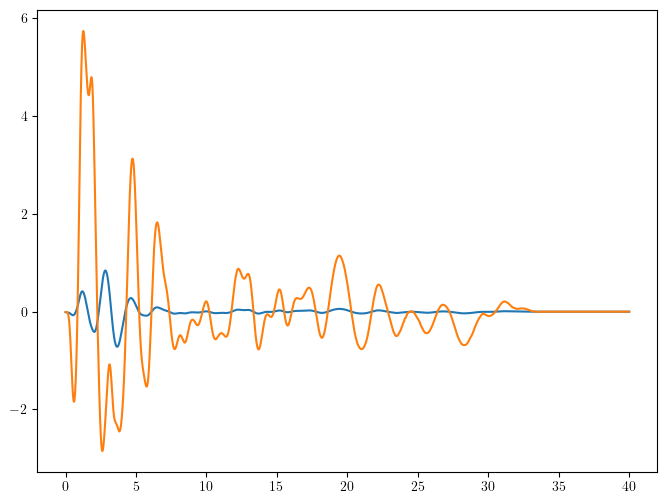

[shot 30] Estimated gather centroid frequency: 492.61 Hz, Wavelet length: 2.03 ms
    iter 01: alpha=2.479e+05, rel||g||=9.715e-01, approx J=-1.059e-04
    iter 02: alpha=4.990e+06, rel||g||=3.627e-01, approx J=-1.932e-03


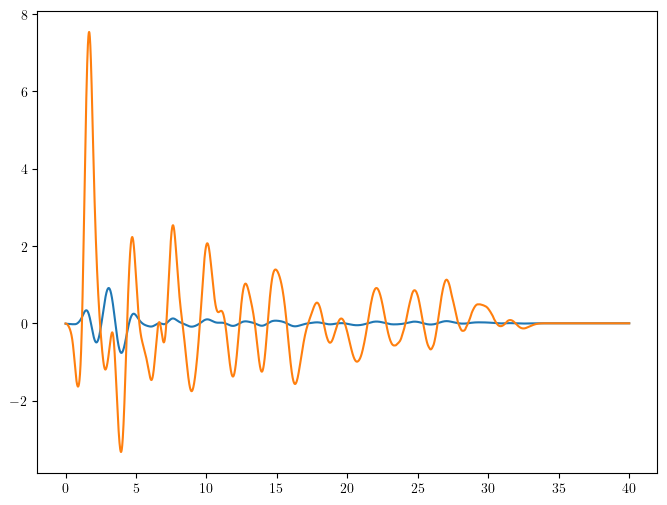

[shot 31] Estimated gather centroid frequency: 480.58 Hz, Wavelet length: 2.08 ms
    iter 01: alpha=2.464e+05, rel||g||=1.000e+00, approx J=4.674e-05
    iter 02: alpha=4.955e+06, rel||g||=4.295e-01, approx J=-2.087e-03


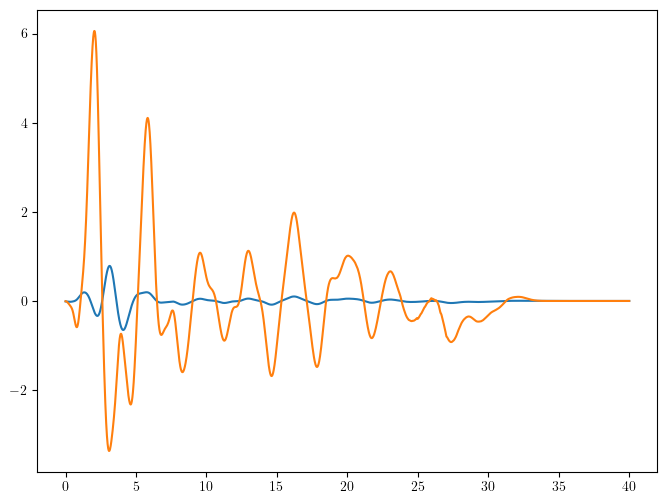

[shot 32] Estimated gather centroid frequency: 500.65 Hz, Wavelet length: 2.00 ms
    iter 01: alpha=2.908e+05, rel||g||=9.704e-01, approx J=-1.456e-04
    iter 02: alpha=5.851e+06, rel||g||=2.470e-01, approx J=-2.749e-03


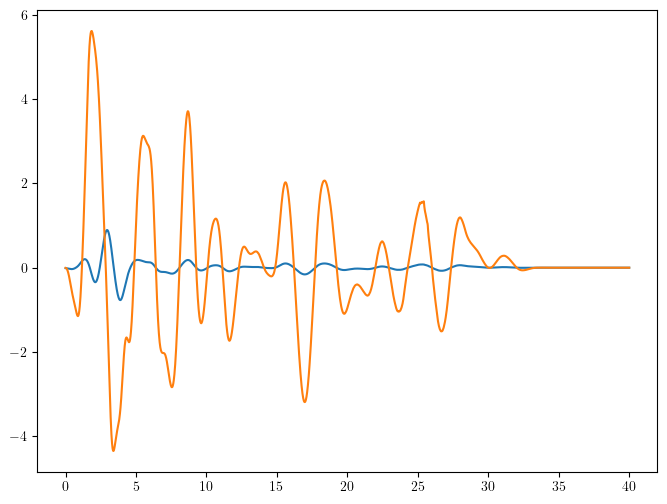

[shot 33] Estimated gather centroid frequency: 502.37 Hz, Wavelet length: 1.99 ms
    iter 01: alpha=3.026e+05, rel||g||=9.704e-01, approx J=-9.472e-05
    iter 02: alpha=6.110e+06, rel||g||=3.751e-01, approx J=-1.927e-03


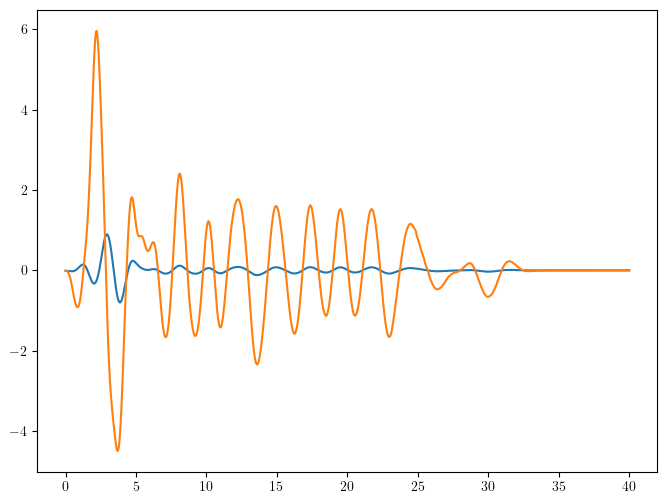

[shot 34] Estimated gather centroid frequency: 460.51 Hz, Wavelet length: 2.17 ms
    iter 01: alpha=3.400e+05, rel||g||=9.927e-01, approx J=-3.727e-05
    iter 02: alpha=6.842e+06, rel||g||=2.520e-01, approx J=-3.480e-03


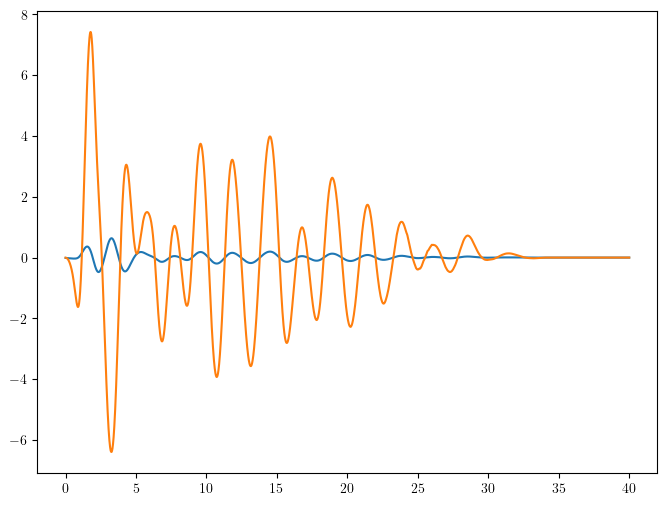

[shot 35] Estimated gather centroid frequency: 449.20 Hz, Wavelet length: 2.23 ms
    iter 01: alpha=3.537e+05, rel||g||=9.318e-01, approx J=-4.264e-04
    iter 02: alpha=7.134e+06, rel||g||=2.521e-01, approx J=-3.174e-03


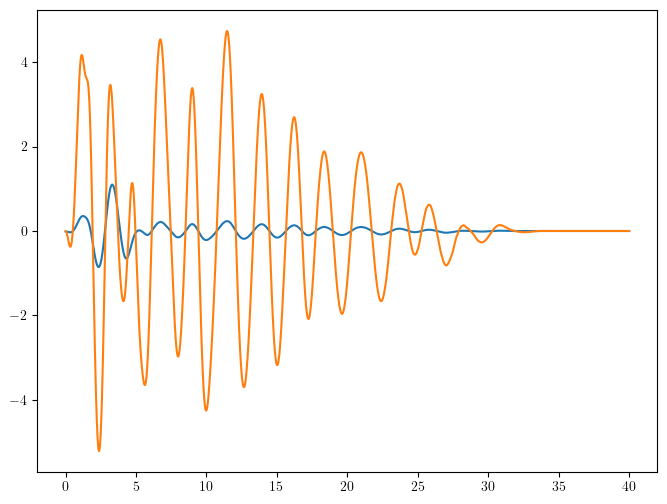

[shot 36] Estimated gather centroid frequency: 522.29 Hz, Wavelet length: 1.91 ms
    iter 01: alpha=2.827e+05, rel||g||=9.214e-01, approx J=-4.634e-04
    iter 02: alpha=5.691e+06, rel||g||=6.980e-01, approx J=-2.995e-03


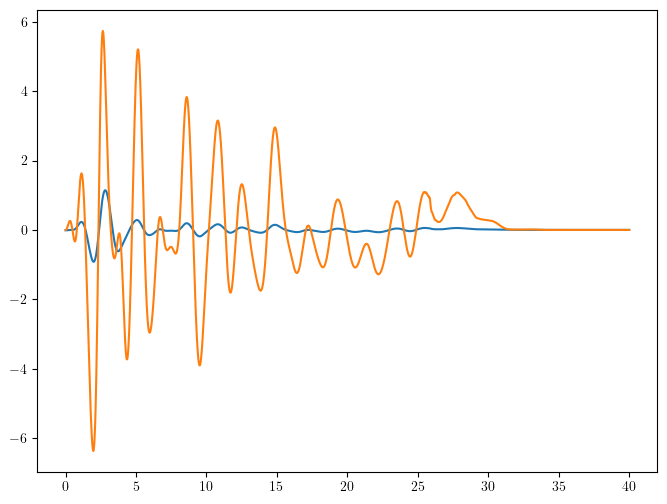

[shot 37] Estimated gather centroid frequency: 494.77 Hz, Wavelet length: 2.02 ms
    iter 01: alpha=3.193e+05, rel||g||=9.508e-01, approx J=-1.063e-03
    iter 02: alpha=6.397e+06, rel||g||=1.334e-01, approx J=-1.135e-02


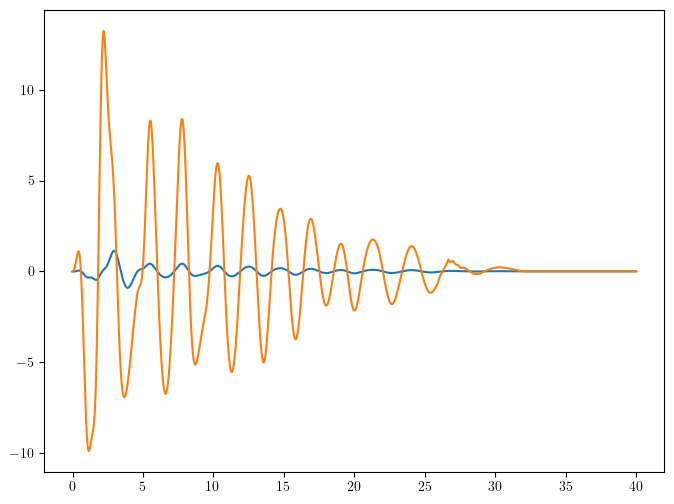

[shot 38] Estimated gather centroid frequency: 490.80 Hz, Wavelet length: 2.04 ms
    iter 01: alpha=2.809e+05, rel||g||=9.438e-01, approx J=-1.059e-03
    iter 02: alpha=5.627e+06, rel||g||=3.376e-01, approx J=-9.844e-03


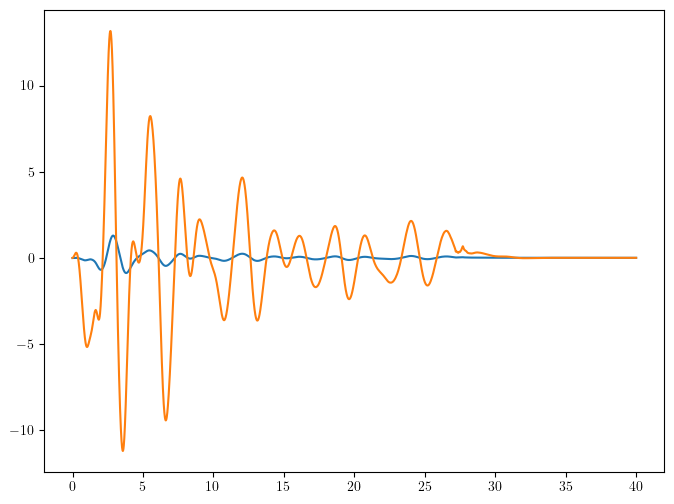

[shot 39] Estimated gather centroid frequency: 445.90 Hz, Wavelet length: 2.24 ms
    iter 01: alpha=2.703e+05, rel||g||=9.531e-01, approx J=-4.245e-04
    iter 02: alpha=5.422e+06, rel||g||=3.294e-01, approx J=-4.954e-03


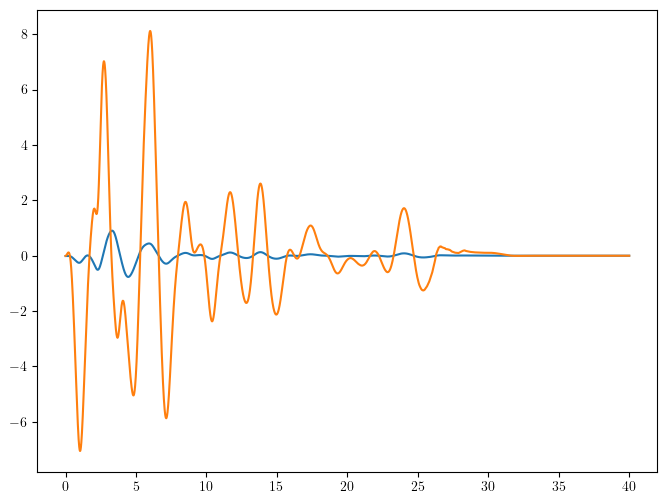

[shot 40] Estimated gather centroid frequency: 470.32 Hz, Wavelet length: 2.13 ms
    iter 01: alpha=2.640e+05, rel||g||=9.501e-01, approx J=-6.576e-04
    iter 02: alpha=5.291e+06, rel||g||=2.899e-01, approx J=-7.104e-03


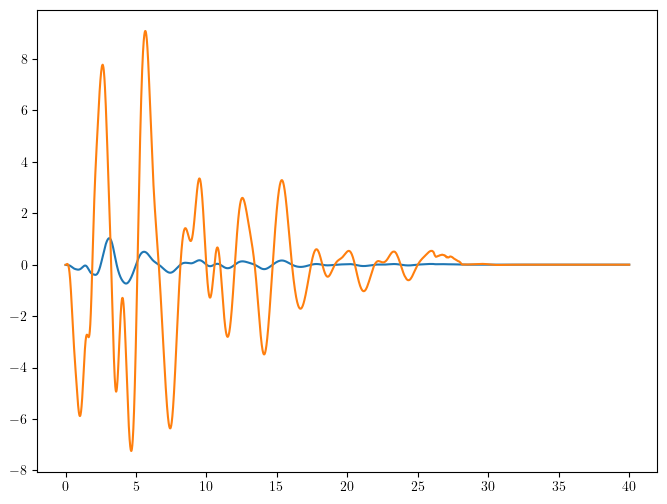

[shot 41] Estimated gather centroid frequency: 454.00 Hz, Wavelet length: 2.20 ms
    iter 01: alpha=2.565e+05, rel||g||=9.303e-01, approx J=-1.235e-03
    iter 02: alpha=5.138e+06, rel||g||=3.278e-01, approx J=-9.157e-03


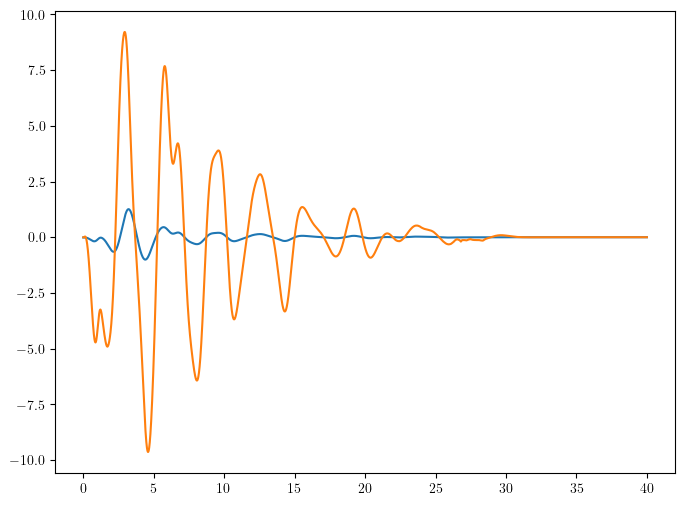

[shot 42] Estimated gather centroid frequency: 447.10 Hz, Wavelet length: 2.24 ms
    iter 01: alpha=2.720e+05, rel||g||=9.249e-01, approx J=-2.610e-03
    iter 02: alpha=5.444e+06, rel||g||=2.923e-01, approx J=-1.784e-02


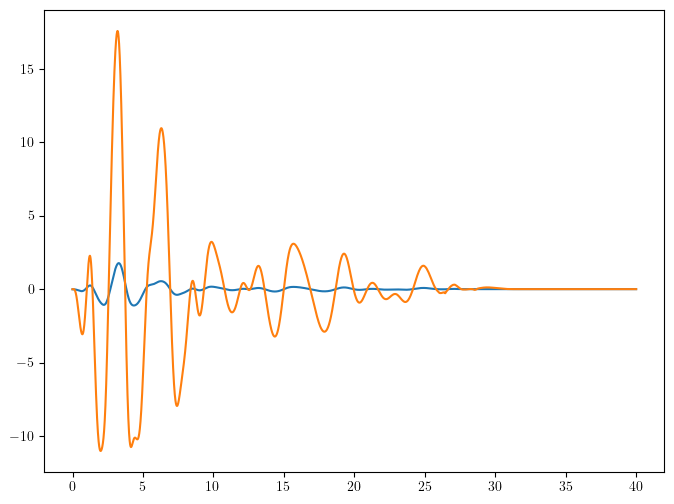

[shot 43] Estimated gather centroid frequency: 460.69 Hz, Wavelet length: 2.17 ms
    iter 01: alpha=2.802e+05, rel||g||=9.334e-01, approx J=-2.536e-03
    iter 02: alpha=5.608e+06, rel||g||=1.479e-01, approx J=-1.950e-02


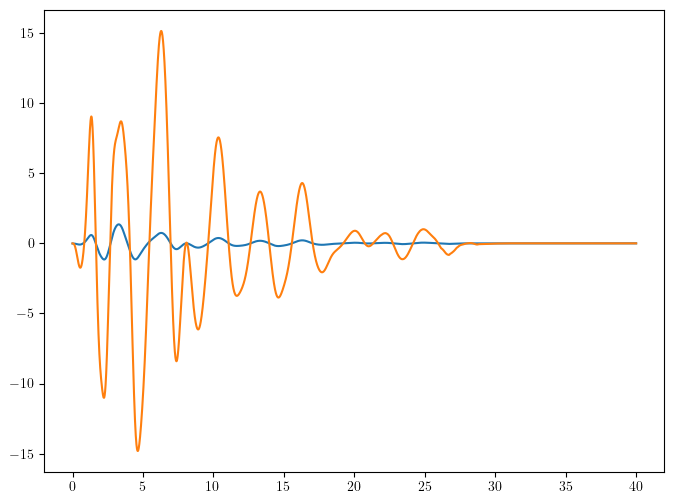

[shot 44] Estimated gather centroid frequency: 473.27 Hz, Wavelet length: 2.11 ms
    iter 01: alpha=2.501e+05, rel||g||=9.637e-01, approx J=-9.363e-04
    iter 02: alpha=5.007e+06, rel||g||=2.920e-01, approx J=-1.362e-02


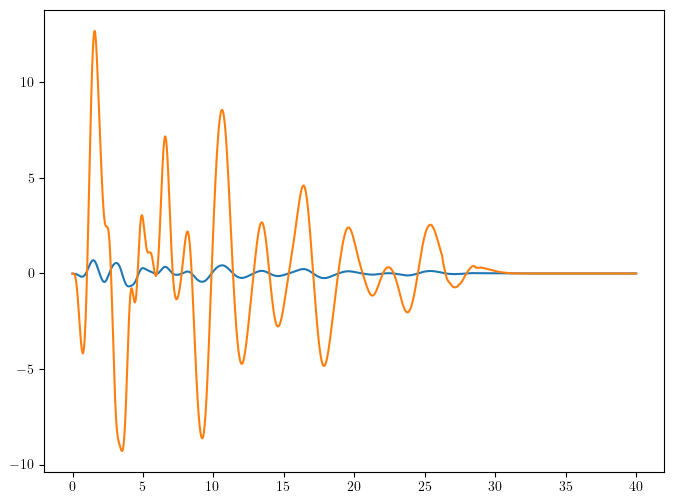

[shot 45] Estimated gather centroid frequency: 435.61 Hz, Wavelet length: 2.30 ms
    iter 01: alpha=2.391e+05, rel||g||=9.602e-01, approx J=-2.353e-03
    iter 02: alpha=4.784e+06, rel||g||=3.281e-01, approx J=-3.021e-02


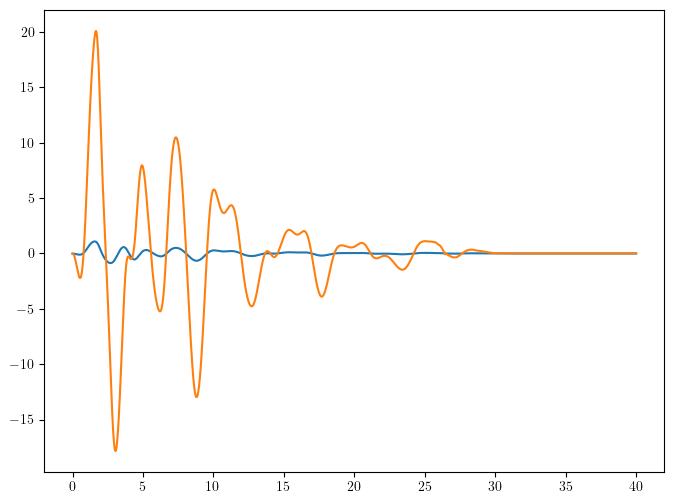

[shot 46] Estimated gather centroid frequency: 458.66 Hz, Wavelet length: 2.18 ms
    iter 01: alpha=2.540e+05, rel||g||=9.642e-01, approx J=-9.113e-04
    iter 02: alpha=5.086e+06, rel||g||=3.526e-01, approx J=-1.274e-02


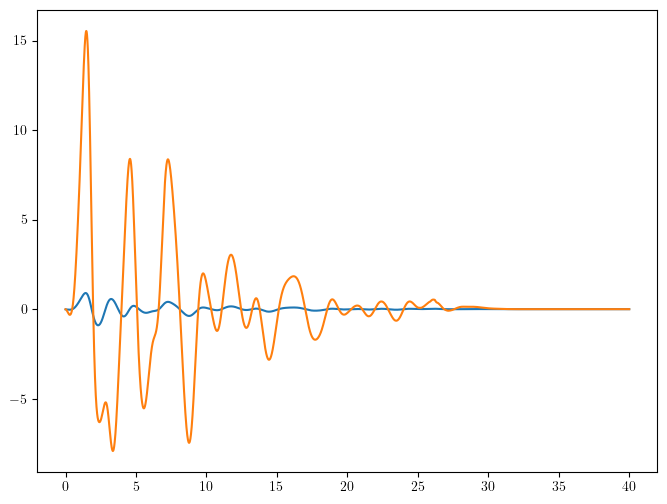

[shot 47] Estimated gather centroid frequency: 426.96 Hz, Wavelet length: 2.34 ms
    iter 01: alpha=2.623e+05, rel||g||=9.784e-01, approx J=-3.656e-04
    iter 02: alpha=5.252e+06, rel||g||=3.447e-01, approx J=-9.290e-03


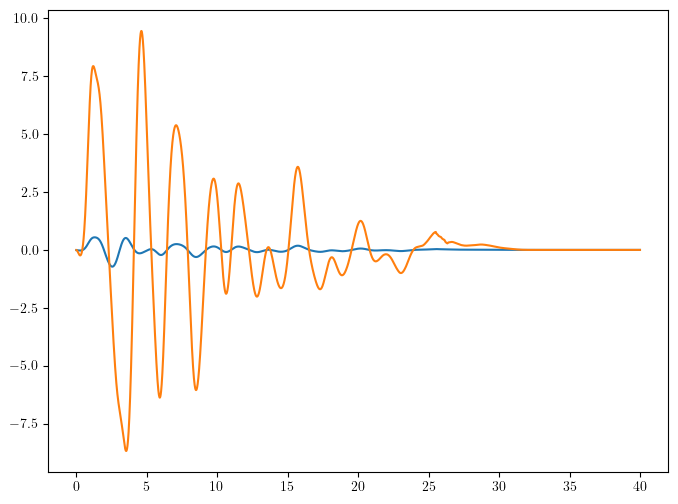

[shot 48] Estimated gather centroid frequency: 466.34 Hz, Wavelet length: 2.14 ms
    iter 01: alpha=3.017e+05, rel||g||=9.777e-01, approx J=-3.003e-04
    iter 02: alpha=6.049e+06, rel||g||=2.416e-01, approx J=-6.888e-03


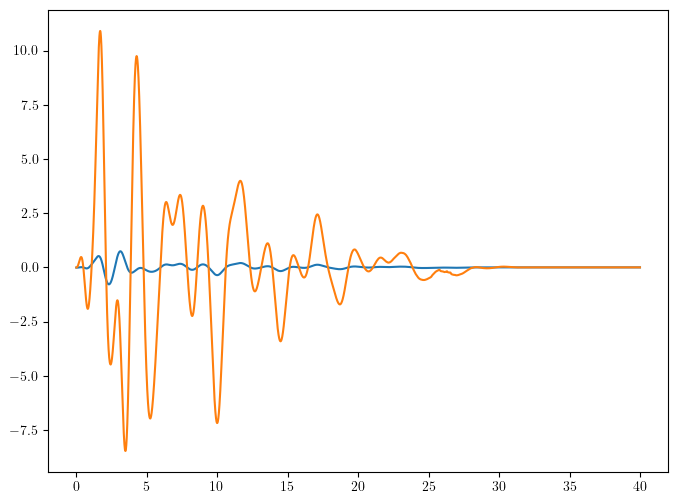

[shot 49] Estimated gather centroid frequency: 419.40 Hz, Wavelet length: 2.38 ms
    iter 01: alpha=3.016e+05, rel||g||=9.508e-01, approx J=-8.177e-04
    iter 02: alpha=6.045e+06, rel||g||=2.756e-01, approx J=-8.385e-03


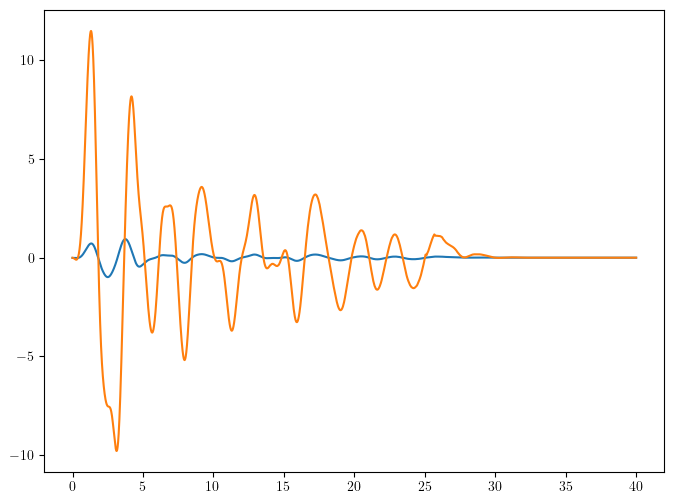

[shot 50] Estimated gather centroid frequency: 456.41 Hz, Wavelet length: 2.19 ms
    iter 01: alpha=3.278e+05, rel||g||=9.533e-01, approx J=-2.909e-04
    iter 02: alpha=6.602e+06, rel||g||=3.254e-01, approx J=-3.151e-03


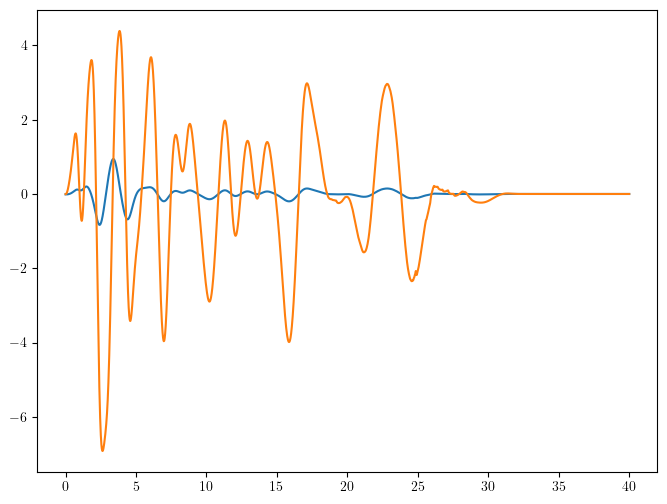

[shot 51] Estimated gather centroid frequency: 432.07 Hz, Wavelet length: 2.31 ms
    iter 01: alpha=3.441e+05, rel||g||=9.428e-01, approx J=-7.666e-04
    iter 02: alpha=6.907e+06, rel||g||=2.203e-01, approx J=-6.650e-03


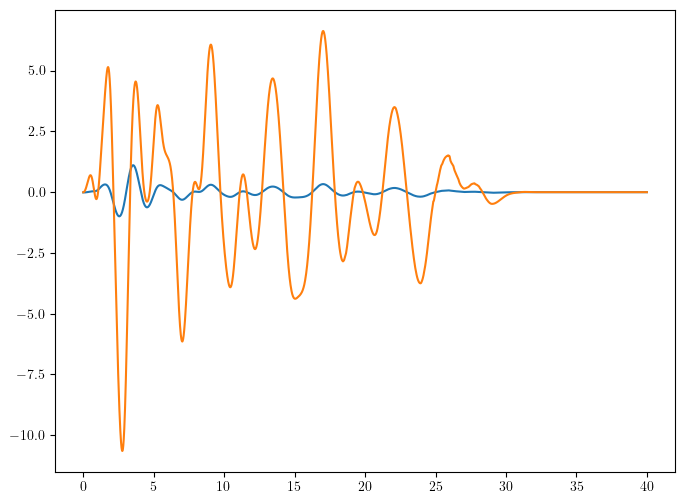

[shot 52] Estimated gather centroid frequency: 441.27 Hz, Wavelet length: 2.27 ms
    iter 01: alpha=3.487e+05, rel||g||=9.425e-01, approx J=-5.601e-04
    iter 02: alpha=7.009e+06, rel||g||=1.895e-01, approx J=-4.943e-03


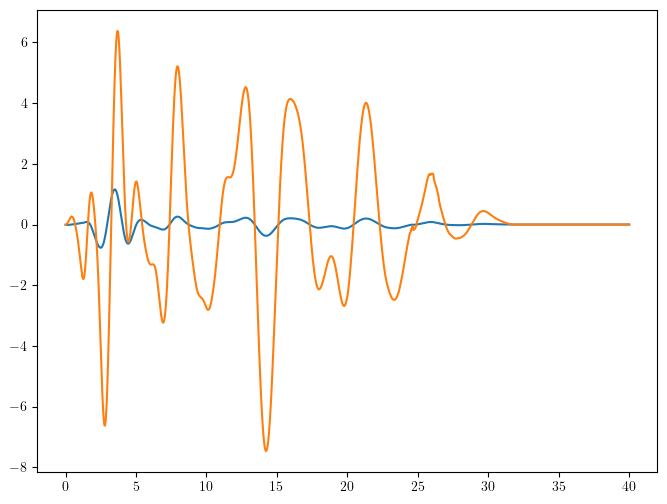

In [15]:
for k in range(len(dataset)):
    d_obs, sx, sz, rec_x, rec_z = dataset[k]
    d_obs /= np.linalg.norm(d_obs)
    f0 = estimate_centroid_frequency_gather(d_obs.T, model.critical_dt) / 1e3
    print(f"[shot {k}] Estimated gather centroid frequency: {f0*1e3:.2f} Hz, Wavelet length: {1/f0:.2f} ms")

    # Geometry / solver
    src_pos = np.array([sx, sz])[None, :]
    rec_pos = np.vstack([rec_x, rec_z]).T
    geometry = AcquisitionGeometry(
        model, rec_pos, src_pos,
        t0, tn, f0=f0 * 2, src_type='Gabor'
    )
    solver = AcousticWaveSolver(model, geometry, space_order=SO)

    current_wavelet = geometry.src.data[:].reshape(-1)
    prev_wavelet = current_wavelet.copy()

    b = precompute_b(model, geometry, solver, d_obs)

    b, window = left_taper_tukey(b.reshape(-1), alpha=0.05)

    # Initial gradient g0 = A f0 - b
    Af = apply_A(model, geometry, solver, current_wavelet, lam=lam)
    g = Af - b
    g_prev = None

    for i in range(max_iter):
        # Exact steepest-descent line search for i==0, else Barzilai–Borwein
        if i == 0:
            # q = A g
            Ag = apply_A(model, geometry, solver, g, lam=lam)
            denom = np.dot(g, Ag) + 1e-18
            alpha = np.dot(g, g) / denom
            alpha *= 0.05
        else:
            s = current_wavelet - prev_wavelet
            y = g - g_prev
            sy = np.dot(s, y)
            yy = np.dot(y, y) + 1e-18
            if abs(sy) > 1e-18:
                alpha = np.dot(s, s) / sy
            else:
                alpha = 1e-3

    #     # Update
        prev_wavelet = current_wavelet
        g_prev = g
        current_wavelet = current_wavelet - alpha * g

        # Recompute gradient at new iterate
        Af = apply_A(model, geometry, solver, current_wavelet, lam=lam)
        g = Af - b

        rel_grad = np.linalg.norm(g) / (np.linalg.norm(b) + 1e-18)
        misfit = 0.5 * np.dot(current_wavelet, Af) - np.dot(current_wavelet, b)  # J up to const (quadratic form)
        print(f"    iter {i+1:02d}: alpha={alpha:.3e}, rel||g||={rel_grad:.3e}, approx J={misfit:.3e}")
        plt.plot(geometry.time_axis.time_values, current_wavelet)
        # Simple stopping
        if rel_grad < 1e-4:
            print("    Converged on wavelet update.")
            break

    plt.show()
    estimated_wavelet = current_wavelet.copy()
    set_wavelet_in_geometry(geometry, estimated_wavelet)
    np.save(f"../adjoint_wavelets/wavelet_{k}_norm.npy", current_wavelet)

In [ ]:
[0, 2, 8, 9, 25, ]